In [21]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [22]:
Churn_data = pd.read_csv('Churn.csv')
Churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [23]:
# Observamos la inormación general del dataset
Churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [24]:
# Identificar variables no informativas, numéricas y categóricas
Churn_data.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure             float64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [25]:
# Identificar variables no informativas, numéricas y categóricas
var_no_informativa = ['RowNumber', 'CustomerId', 'Surname']
var_numerica = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'IsActiveMember', 'HasCrCard']
var_categorica = ['Geography', 'Gender']

In [26]:
# Eliminaremos las variables no informativas
Churn_data = Churn_data.drop(var_no_informativa, axis=1)

In [27]:
# Convertiremos las variables categóricas a numéricas
Churn_data = pd.get_dummies(Churn_data, drop_first=True, columns=var_categorica)


In [28]:
Churn_data

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1.0,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8.0,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1.0,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2.0,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5.0,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10.0,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7.0,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3.0,75075.31,2,1,0,92888.52,1,True,False,True


In [29]:
# Reemplazaremos los valores nulos con la mediana de la columna Tenure
Churn_data['Tenure'] = Churn_data['Tenure'].fillna(value=Churn_data['Tenure'].median())

In [32]:
# Dividir datos de prueba y entrenamiento
from sklearn.model_selection import train_test_split

train_valid, test = train_test_split(Churn_data, test_size=0.2)
train, valid = train_test_split(train_valid, test_size=0.25)

features_train = train.drop(['Exited'], axis=1)
target_train = train['Exited']

features_valid = valid.drop(['Exited'], axis=1)
target_valid = valid['Exited']

features_test = test.drop(['Exited'], axis=1)
target_test = test['Exited']    

print('Set de entrenamiento:', features_train.shape)
print('Set de validación:', features_valid.shape)
print('Set de prueba:', features_test.shape)    

Set de entrenamiento: (6000, 11)
Set de validación: (2000, 11)
Set de prueba: (2000, 11)


In [33]:
# Estandarizar los datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_train[var_numerica] = scaler.fit_transform(features_train[var_numerica])
features_valid[var_numerica] = scaler.transform(features_valid[var_numerica])
features_test[var_numerica] = scaler.transform(features_test[var_numerica])

Revisaremos ahora si tenemos algún desbalance en los datos


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.3 MB 13.4 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 19.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 18.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 24.8 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Exited
0    0.800333
1    0.199667
Name: proportion, dtype: float64


<Axes: xlabel='Exited'>

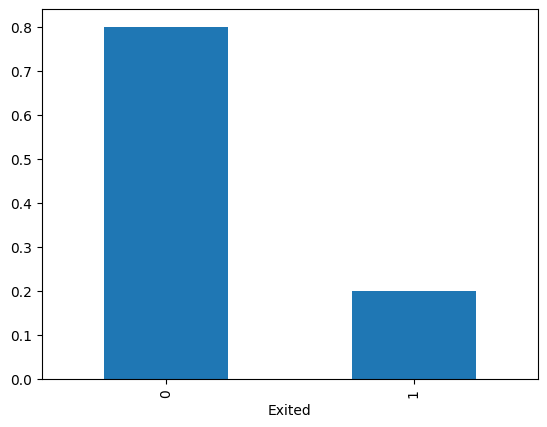

In [36]:
%pip install matplotlib
from matplotlib import pyplot as plt

# Revisamos el posible desbalance de datos
print(target_train.value_counts(normalize=True))
target_train.value_counts(normalize=True).plot(kind='bar')